### GLM Expected Goals Model 

- Create an Expected Goals model using statcast data
- Have three datasets, full_features, semi_full_features, and simple model
- Conduct Data Analysis on each individual feature 

Propose a Model 
- Validate Results

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    log_loss,
    brier_score_loss,
    roc_curve
)
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer

In [5]:
full_features_df = pd.read_csv("data/glm_model_full_feature.csv")
semi_full_df = pd.read_csv("data/glm_model_semi_full.csv")
simple_model_df = pd.read_csv("data/glm_model_simple.csv")

### Shot Dataset
- All from statsbomb open data including multiple leagues 
- 40,000 total shots being used
- statsbomb includes 360 freeze frame data in this dataset, which is the data points of players off the ball

In [6]:
full_features_df.describe()

,statsbomb_match_id,statsbomb_player_id,statsbomb_team_id,statsbomb_x,statsbomb_y,shot_angle,shot_distance,defensive_pressure,goalkeeper_shooter_distance,goalkeeper_shooter_angle,players_between_shooter_and_goal,shot_statsbomb_xg,is_goal,goalkeeper_shooter_distance_angle,shot_distance_angle
count,4.000000e+04,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,39422.000000,39422.000000,40000.000000,40000.000000,40000.000000,39422.000000,40000.000000
mean,3.136382e+06,23440.260325,664.185475,103.455210,39.747667,25.025203,19.339462,0.122550,16.319670,0.078877,1.710450,0.105549,0.110550,0.770184,383.874483
std,1.465131e+06,59328.518697,1530.728491,8.780656,9.951209,15.324712,8.712228,0.356349,8.907060,0.181693,1.045795,0.150071,0.313578,1.372878,71.726966
min,7.525000e+03,2935.000000,1.000000,35.400000,0.300000,0.000000,0.632456,0.000000,0.360555,0.000000,0.000000,0.000180,0.000000,0.000000,0.000000
25%,3.754096e+06,5207.000000,146.000000,97.100000,32.400000,14.975441,12.150823,0.000000,8.965210,0.014807,1.000000,0.027524,0.000000,0.238467,352.724425
50%,3.825807e+06,6963.000000,217.000000,104.900000,40.000000,19.554594,18.652882,0.000000,15.207728,0.035127,1.000000,0.053673,0.000000,0.522843,406.746963
75%,3.888787e+06,17045.000000,290.000000,110.400000,47.100000,30.897548,25.612741,0.000000,22.999565,0.074395,2.000000,0.107702,0.000000,0.955319,438.000602
max,3.943077e+06,435137.000000,17469.000000,120.200000,79.600000,180.000000,86.137100,4.000000,74.030872,3.094589,9.000000,0.995122,1.000000,102.334312,484.558198


### Data Analysis of Features

### Analysis of Shot Distance and Shot Angle 
- Thought process here is, the closer and more central a shot is, the higher the probability of scoring a goal 
- The larger the angle created between the shooter and the two posts of the net, the higher the probability of scoring a goal. (demonstrated in the images below)

In [7]:
full_features_df

,statsbomb_event_id,statsbomb_match_id,statsbomb_player_id,player,statsbomb_team_id,team,location,play_pattern,statsbomb_x,statsbomb_y,...,goalkeeper_shooter_distance,goalkeeper_shooter_angle,players_between_shooter_and_goal,is_open_goal,shot_statsbomb_xg,shot_outcome,last_updated,is_goal,goalkeeper_shooter_distance_angle,shot_distance_angle
0,0c38c9e3-726f-45eb-9d77-4d43950332e3,266560.0,20542.0,Álvaro Negredo Sánchez,207.0,Valencia,"[74.3, 26.2]",Regular Play,74.3,26.2,...,44.240366,0.026344,1,False,0.006428,Saved,2026-03-25 21:09:06.698448,0.0,1.165450,438.113505
1,d016b1d7-f487-4b9d-ba2e-01d796992a84,3890479.0,6317.0,Marco Jhonfai Fabián De La Mora,184.0,Eintracht Frankfurt,"[100.1, 31.5]",From Throw In,100.1,31.5,...,18.668155,0.048042,1,False,0.036239,Off T,2026-03-25 21:09:06.698448,0.0,0.896861,419.642027
2,0a1d4ed6-e02e-4c1e-a878-acf5b4fad85b,3879613.0,7150.0,Riccardo Saponara,290.0,Empoli,"[89.6, 38.8]",From Free Kick,89.6,38.8,...,27.611592,0.010476,2,False,0.025506,Blocked,2026-03-26 21:23:57.546325,0.0,0.289254,455.413445
3,21f484b4-58b6-4cf5-9f6b-cc973c835e63,69171.0,19298.0,Samuel Eto''o Fils,217.0,Barcelona,"[107.2, 41.5]",Regular Play,107.2,41.5,...,12.192621,0.239993,1,False,0.244035,Wayward,2026-03-26 21:23:57.546325,0.0,2.926145,442.096553
4,cd658acc-409b-4d53-af87-f2ad1f5871df,3754022.0,3693.0,Damien Delaney,31.0,Crystal Palace,"[108.5, 42.5]",From Corner,108.5,42.5,...,10.756393,0.111617,4,False,0.041777,Wayward,2026-03-25 21:09:06.698448,0.0,1.200595,434.347300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,a4fa613d-4091-469b-bff8-5de9e4a42b66,3879576.0,27595.0,Carlos Mario Carbonero Mancilla,234.0,Sampdoria,"[112.3, 37.8]",From Throw In,112.3,37.8,...,6.576473,0.125650,1,False,0.404889,Off T,2026-03-26 21:23:57.546325,0.0,0.826336,416.409310
39996,0ed19467-b3a8-46f4-88c0-d15a0e5dff2d,3879675.0,8172.0,Felipe Anderson Pereira Gomes,236.0,Lazio,"[83.6, 45.8]",Regular Play,83.6,45.8,...,35.034412,0.000372,1,False,0.006113,Wayward,2026-03-26 21:23:57.546325,0.0,0.013023,451.063858
39997,6785e5d7-87d2-448f-ac19-c26800ee96ad,3817873.0,124772.0,Pritam Kotal,7282.0,ATK Mohun Bagan,"[113.2, 37.6]",From Corner,113.2,37.6,...,6.580274,0.046380,3,False,0.088774,Off T,2026-03-26 21:23:57.546325,0.0,0.305195,407.462018
39998,591ccc6e-c1fb-4548-b2d4-02e32ba06e64,3817878.0,33419.0,Joel Joseph Chianese,7289.0,Hyderabad,"[113.5, 31.1]",Regular Play,113.5,31.1,...,8.848164,0.030256,1,False,0.159080,Off T,2026-03-26 21:23:57.546325,0.0,0.267714,289.264066


### Analysis of shot body part, shot technique, play_pattern, shot_first_time
- Expectation is that shots with feet should increase the probability of scoring a goal as opposed to head, as players have more control with their feet, and tend to be on the ground
- Shot technique, expectation is that shots from feet, or regular have larger probabilities of scoring than volleys, or backheels as those are more difficult techniques 
- Shot First Time --> compelling research shows that first time shots should increase the probability of scoring a goal 
- Play Pattern -> penalties should have the highest probability of scoring, then set pieces, then regular play, due to no defenders interfering with play

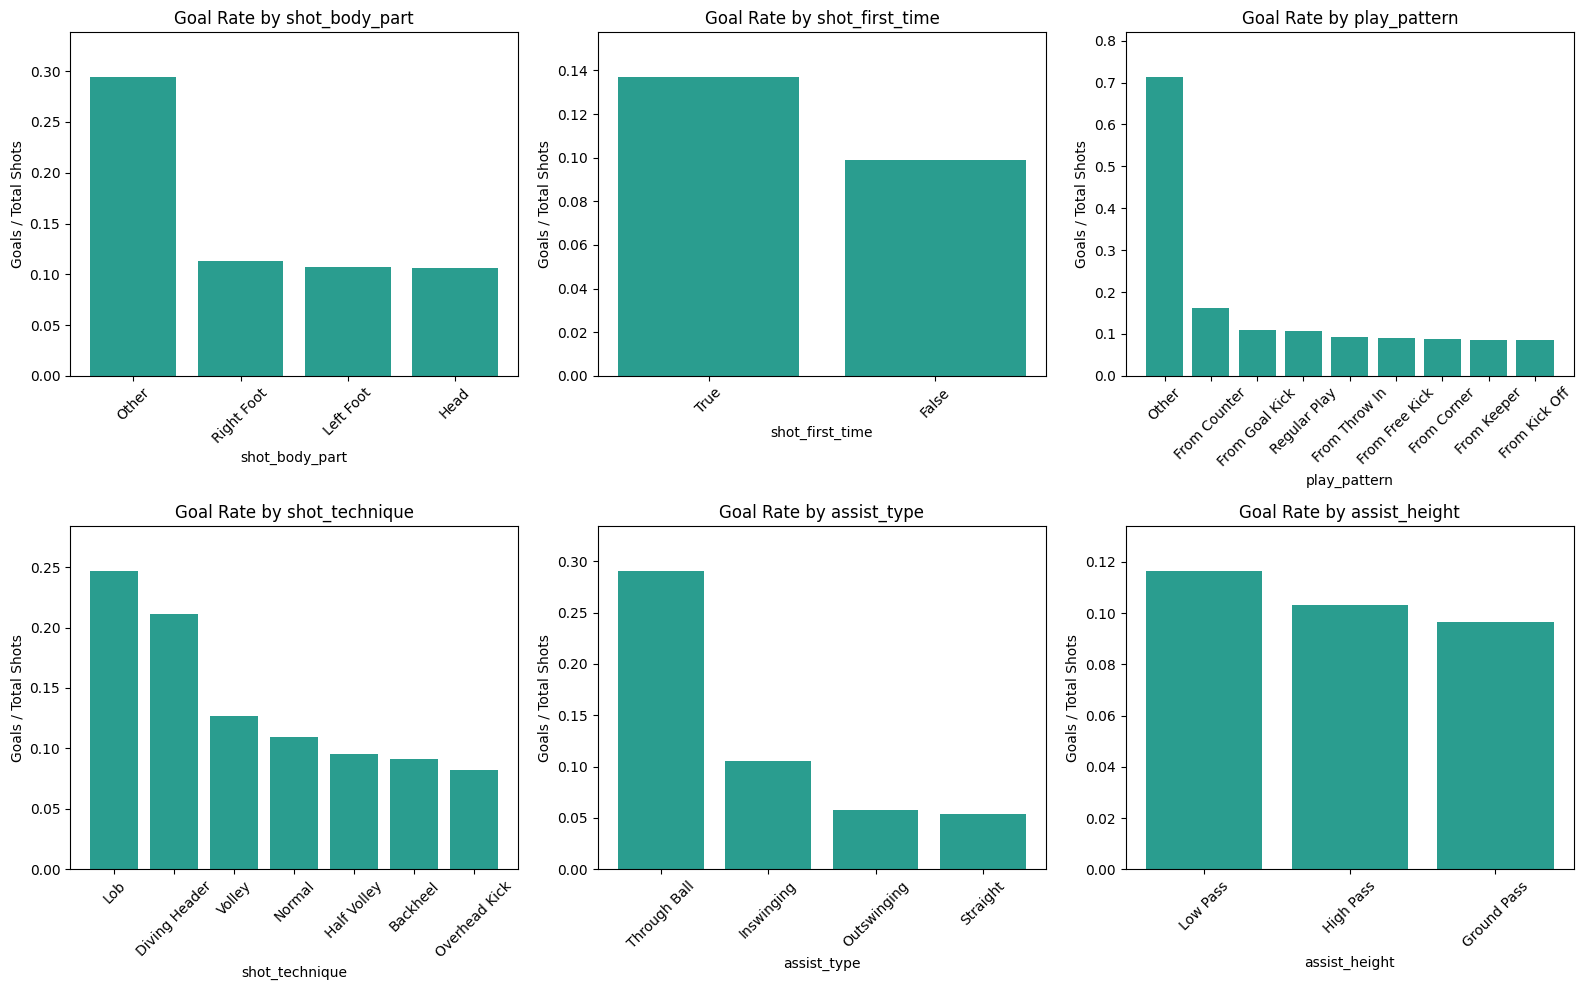

In [10]:
# 2x2 subplot: goal conversion rate (total goals / total shots) by category
df = full_features_df.copy()

features = [
    "shot_body_part",
    "shot_first_time",
    "play_pattern",
    "shot_technique",
    "assist_type",
    "assist_height",
]

if "is_goal" not in df.columns:
    raise ValueError("Column 'is_goal' not found in dataframe.")

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    if feature not in df.columns:
        ax.set_title(f"{feature} (column not found)")
        ax.axis("off")
        continue

    feature_df = (
        df[[feature, "is_goal"]]
        .dropna(subset=[feature])
        .assign(is_goal=lambda x: pd.to_numeric(x["is_goal"], errors="coerce"))
        .dropna(subset=["is_goal"])
    )

    conversion = (
        feature_df.groupby(feature, as_index=False)["is_goal"]
        .agg(total_goals="sum", total_shots="count")
    )
    conversion["goal_rate"] = conversion["total_goals"] / conversion["total_shots"]
    conversion = conversion.sort_values("goal_rate", ascending=False)

    ax.bar(conversion[feature].astype(str), conversion["goal_rate"], color="#2a9d8f")
    ax.set_title(f"Goal Rate by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Goals / Total Shots")
    ax.tick_params(axis="x", rotation=45)
    ax.set_ylim(0, min(1.0, conversion["goal_rate"].max() * 1.15 if len(conversion) else 1.0))

plt.tight_layout()
plt.show()

- Data shows that stratification by feature clearly shows an impact on goal rates 
- The type of categorical metric has an impact of probability of scoring a goal, and can be used as feature 

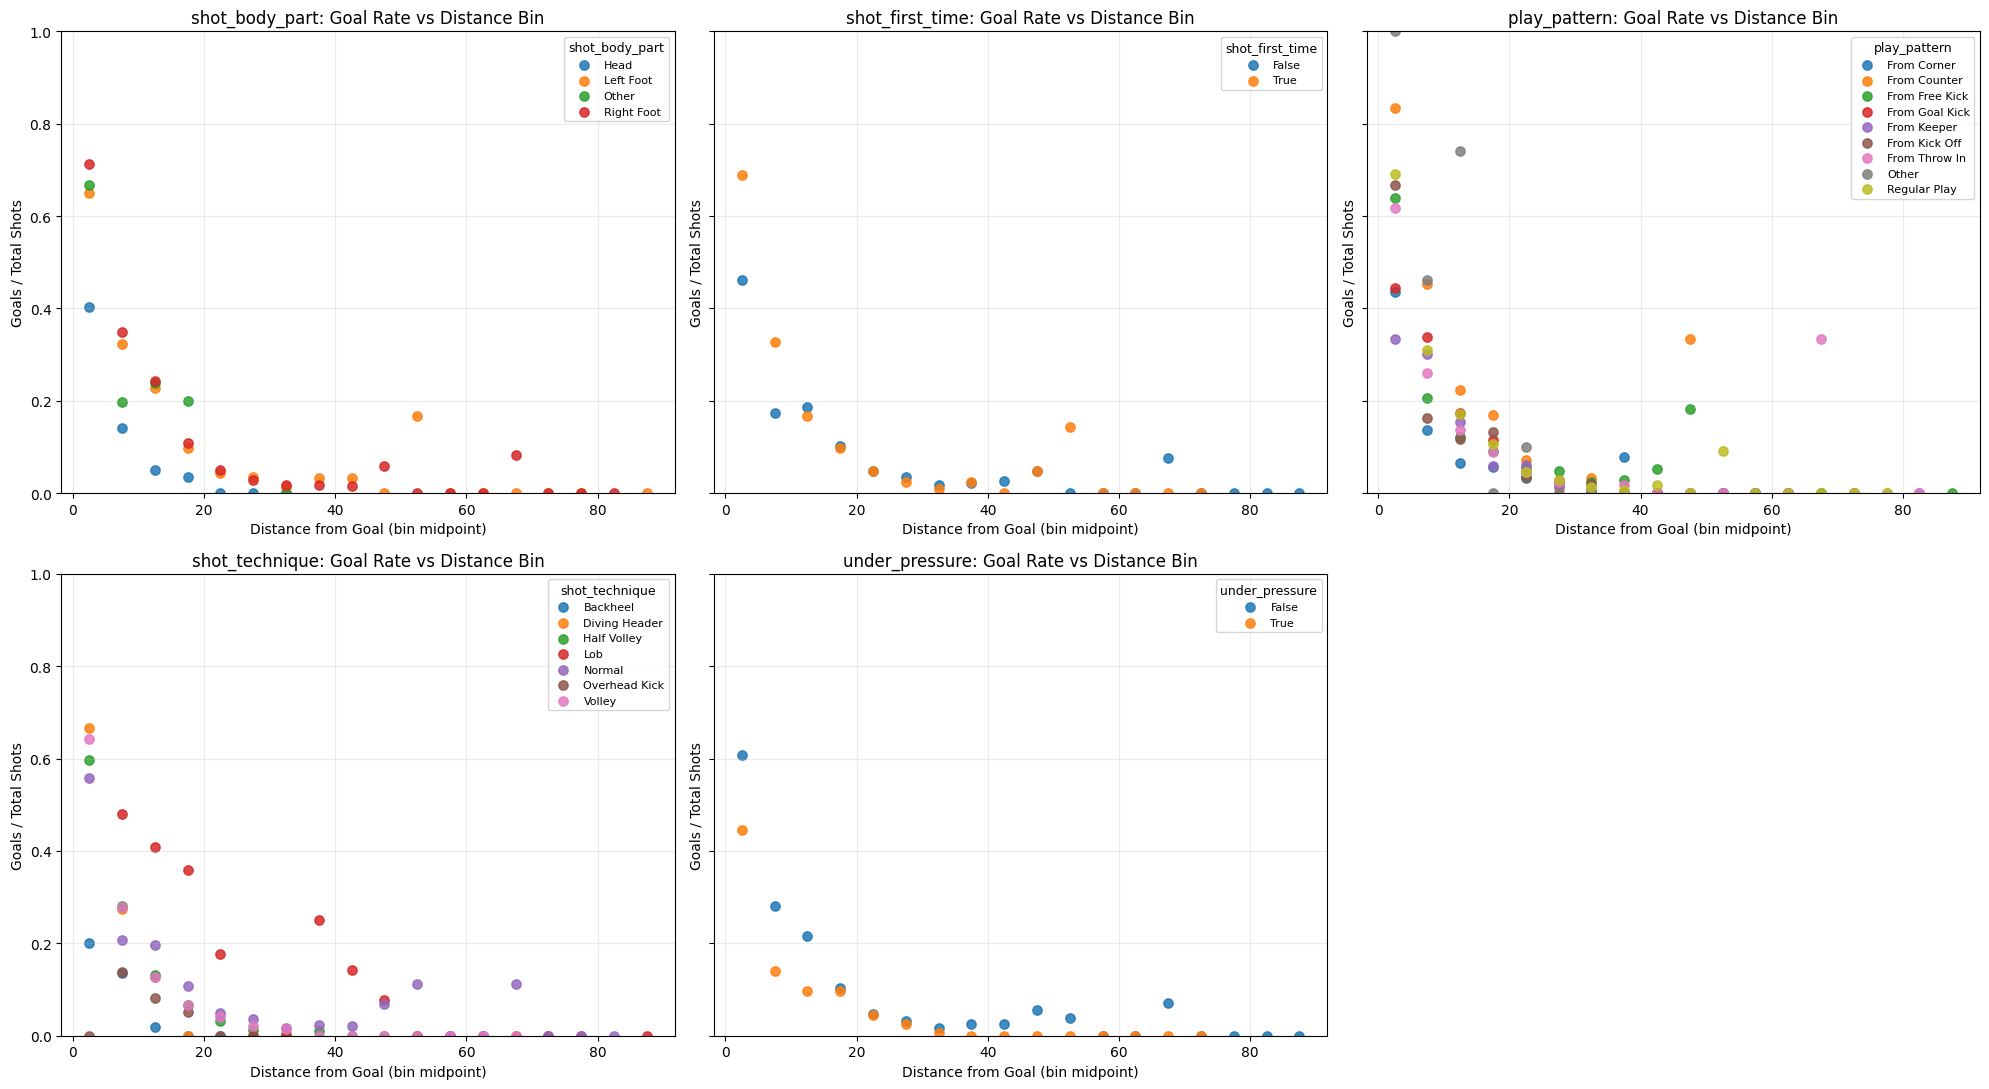

In [11]:
# 2x3 scatter plots: goal rate by distance bin, colored by category
df = full_features_df.copy()

required_cols = ["statsbomb_x", "statsbomb_y", "is_goal"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

# Preferred categorical fields for 2x3 grid
candidate_features = [
    "shot_body_part",
    "shot_first_time",
    "play_pattern",
    "shot_technique",
    "shot_type",
    "under_pressure",
]

# Keep only features that exist in this dataset
features = [f for f in candidate_features if f in df.columns][:6]

# Distance to center of goal at the end of a 120x80 pitch -> (120, 40)
plot_df = df.copy()
plot_df["is_goal"] = pd.to_numeric(plot_df["is_goal"], errors="coerce")
plot_df = plot_df.dropna(subset=["statsbomb_x", "statsbomb_y", "is_goal"])
plot_df["distance_to_goal"] = np.sqrt((120 - plot_df["statsbomb_x"]) ** 2 + (40 - plot_df["statsbomb_y"]) ** 2)

max_dist = np.ceil(plot_df["distance_to_goal"].max() / 5) * 5
bin_edges = np.arange(0, max_dist + 5, 5)
if len(bin_edges) < 2:
    bin_edges = np.array([0, 5])

plot_df["distance_bin"] = pd.cut(
    plot_df["distance_to_goal"],
    bins=bin_edges,
    include_lowest=True,
    right=False
)
plot_df["bin_mid"] = plot_df["distance_bin"].apply(
    lambda b: (b.left + b.right) / 2 if pd.notna(b) else np.nan
)

fig, axes = plt.subplots(2, 3, figsize=(20, 11), sharey=True)
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(features):
        ax.axis("off")
        continue

    feature = features[i]
    tmp = plot_df.dropna(subset=[feature, "distance_bin"]).copy()

    grouped = (
        tmp.groupby(["bin_mid", feature], as_index=False)["is_goal"]
        .agg(total_goals="sum", total_shots="count")
    )
    grouped["goal_rate"] = grouped["total_goals"] / grouped["total_shots"]

    for category, part in grouped.groupby(feature):
        ax.scatter(
            part["bin_mid"],
            part["goal_rate"],
            s=45,
            alpha=0.85,
            label=str(category)
        )

    ax.set_title(f"{feature}: Goal Rate vs Distance Bin")
    ax.set_xlabel("Distance from Goal (bin midpoint)")
    ax.set_ylabel("Goals / Total Shots")
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.25)
    ax.legend(title=feature, fontsize=8, title_fontsize=9, loc="best")

plt.tight_layout()
plt.show()


- Clear correlation between distance and goal rate, closer distances higher goal rate for each feature
- Shows that data has a directional component with count component

### Analysis of Advanced Features 
- Due to 360 statscast data, advanced components can be calculated 
- Goalkeeper Shooter Distance
  - distance from goalkeeper to shooter 
  - expectation being that goal rates should be higher at medium to lower distances 

- There should be some interaction with angle and shooter distance because, if distnace is low by net is open, determined by angle you should see higher goal probabilities

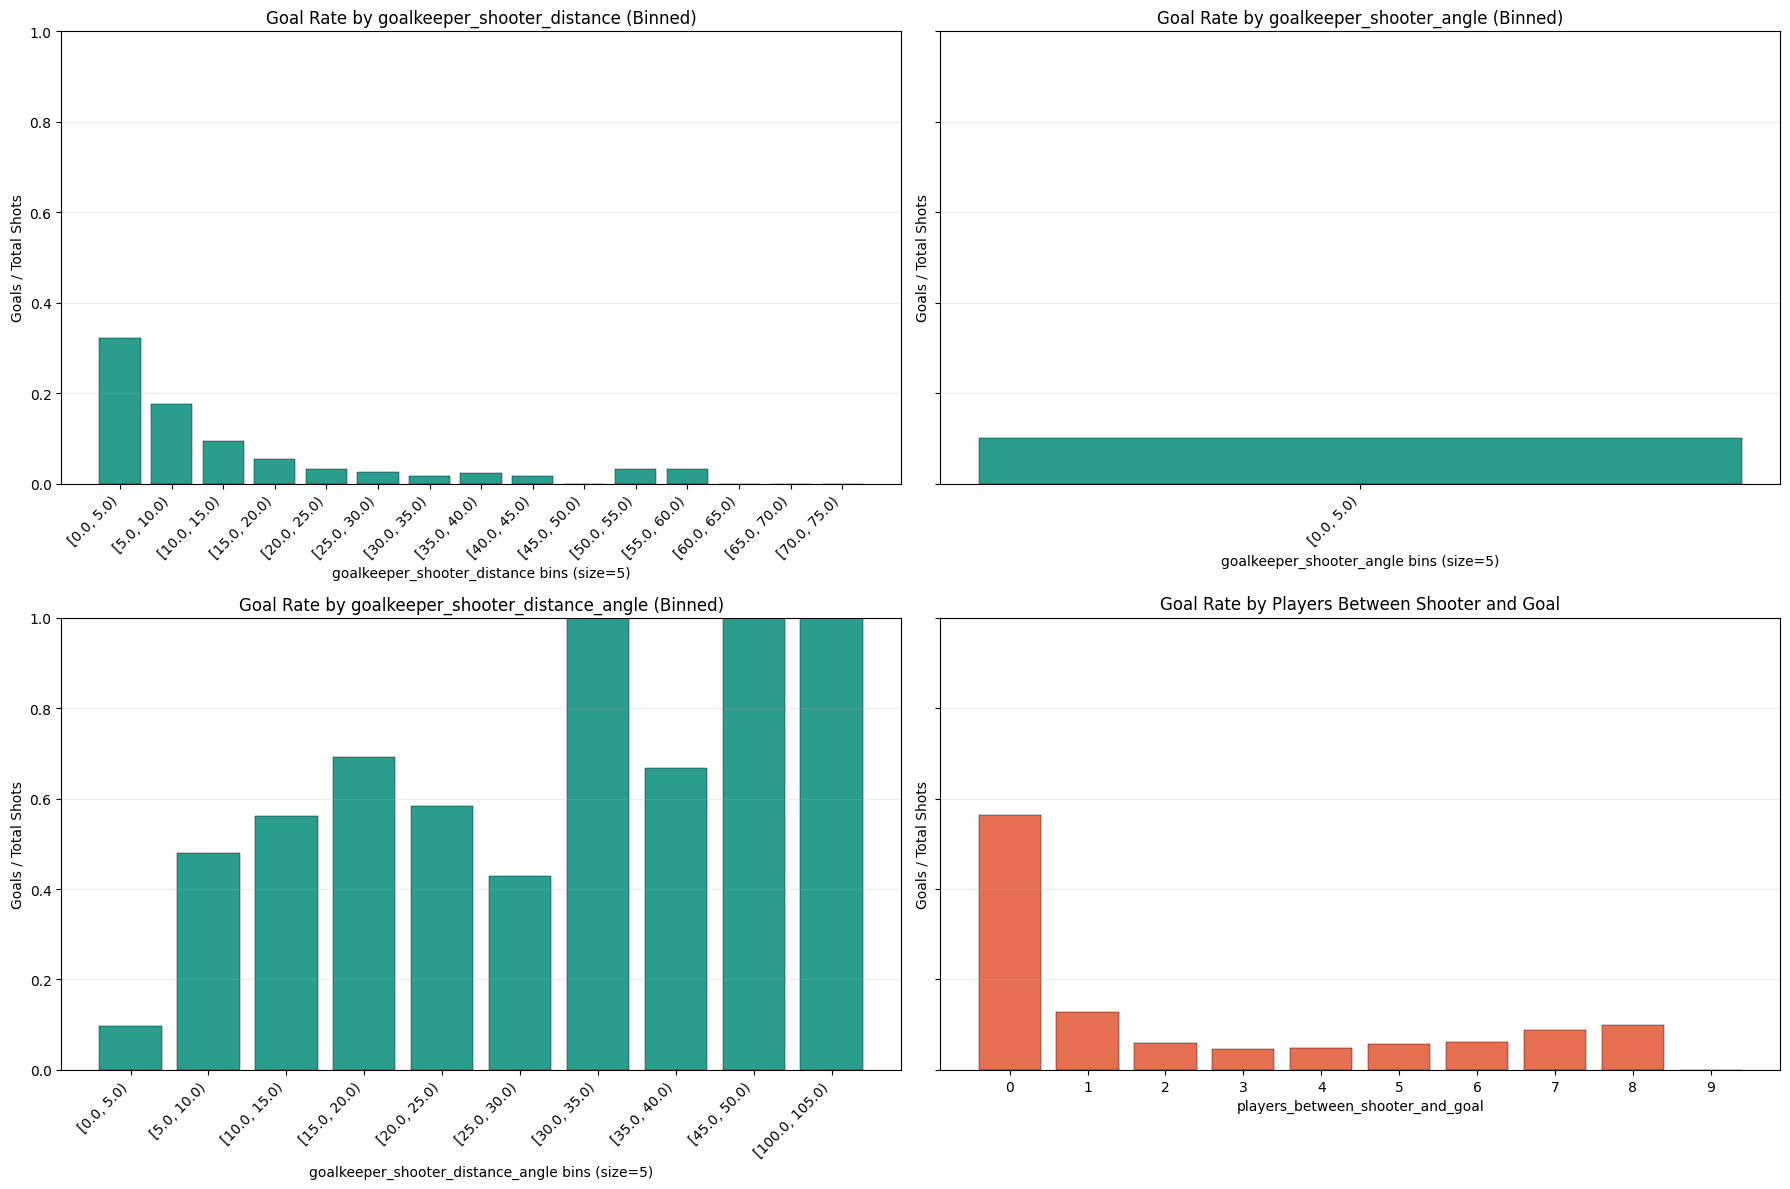

In [15]:
features_of_interes = [
    "goalkeeper_shooter_distance",
    "goalkeeper_shooter_angle",
    "players_between_shooter_and_goal",
]

df = full_features_df.copy()

if "is_goal" not in df.columns:
    raise ValueError("Column 'is_goal' not found in dataframe.")

# Build interaction feature if missing and source features exist
if (
    "goalkeeper_shooter_distance_angle" not in df.columns
    and "goalkeeper_shooter_distance" in df.columns
    and "goalkeeper_shooter_angle" in df.columns
):
    df["goalkeeper_shooter_distance_angle"] = (
        pd.to_numeric(df["goalkeeper_shooter_distance"], errors="coerce")
        * pd.to_numeric(df["goalkeeper_shooter_angle"], errors="coerce")
    )


def plot_binned_goal_rate(ax, data, feature, bin_size=5):
    tmp = data[[feature, "is_goal"]].copy()
    tmp[feature] = pd.to_numeric(tmp[feature], errors="coerce")
    tmp["is_goal"] = pd.to_numeric(tmp["is_goal"], errors="coerce")
    tmp = tmp.dropna(subset=[feature, "is_goal"])

    if tmp.empty:
        ax.set_title(f"{feature} (no valid data)")
        ax.axis("off")
        return

    min_v = np.floor(tmp[feature].min() / bin_size) * bin_size
    max_v = np.ceil(tmp[feature].max() / bin_size) * bin_size
    edges = np.arange(min_v, max_v + bin_size, bin_size)
    if len(edges) < 2:
        edges = np.array([min_v, min_v + bin_size])

    tmp["bin"] = pd.cut(tmp[feature], bins=edges, include_lowest=True, right=False)

    agg = (
        tmp.groupby("bin", observed=False, as_index=False)["is_goal"]
        .agg(total_goals="sum", total_shots="count")
    )
    agg["goal_rate"] = agg["total_goals"] / agg["total_shots"]

    # Keep bins with at least one shot
    agg = agg[agg["total_shots"] > 0].copy()
    if agg.empty:
        ax.set_title(f"{feature} (no shots in bins)")
        ax.axis("off")
        return

    labels = [f"[{b.left:.1f}, {b.right:.1f})" for b in agg["bin"]]
    x = np.arange(len(agg))

    ax.bar(x, agg["goal_rate"], color="#2a9d8f", edgecolor="black", linewidth=0.3)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_ylim(0, 1)
    ax.set_ylabel("Goals / Total Shots")
    ax.set_xlabel(f"{feature} bins (size={bin_size})")
    ax.set_title(f"Goal Rate by {feature} (Binned)")
    ax.grid(axis="y", alpha=0.25)


def plot_players_between_bar(ax, data):
    feature = "players_between_shooter_and_goal"
    tmp = data[[feature, "is_goal"]].copy()
    tmp[feature] = pd.to_numeric(tmp[feature], errors="coerce")
    tmp["is_goal"] = pd.to_numeric(tmp["is_goal"], errors="coerce")
    tmp = tmp.dropna(subset=[feature, "is_goal"])

    if tmp.empty:
        ax.set_title(f"{feature} (no valid data)")
        ax.axis("off")
        return

    tmp[feature] = tmp[feature].astype(int)

    agg = (
        tmp.groupby(feature, as_index=False)["is_goal"]
        .agg(total_goals="sum", total_shots="count")
        .sort_values(feature)
    )
    agg["goal_rate"] = agg["total_goals"] / agg["total_shots"]

    ax.bar(agg[feature].astype(str), agg["goal_rate"], color="#e76f51", edgecolor="black", linewidth=0.3)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Goals / Total Shots")
    ax.set_xlabel(feature)
    ax.set_title("Goal Rate by Players Between Shooter and Goal")
    ax.grid(axis="y", alpha=0.25)


fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
axes = axes.flatten()

binned_features = [
    "goalkeeper_shooter_distance",
    "goalkeeper_shooter_angle",
    "goalkeeper_shooter_distance_angle",
]

for i, feature in enumerate(binned_features):
    if feature in df.columns:
        plot_binned_goal_rate(axes[i], df, feature, bin_size=5)
    else:
        axes[i].set_title(f"{feature} (column not found)")
        axes[i].axis("off")

if "players_between_shooter_and_goal" in df.columns:
    plot_players_between_bar(axes[3], df)
else:
    axes[3].set_title("players_between_shooter_and_goal (column not found)")
    axes[3].axis("off")

plt.tight_layout()
plt.show()


- Looking at binned features a few things stand out: 
    - smaller goalkeeper shooter distance, higher the goal rate, however this can be misleading as if the goalkeeper is behind player by a large distance, as you see in the two outliers your goal rate can still increase. This is likely why you see at very large distances, (50,55) and (60,65) to have higher goal rates. 
    - combining goalkeeper shooter distance and angle is a better metric, shows a decent postive relationship or right skewed of larger goalkeeper shooter distances time angle, resulted in larger goal rates. ** look at this carefully
    - players between shooter and goal are right skewed as 0 players between shooter and goal has a much larger goal rate, what is interesting is 7,8 are larger than 6. What this could mean is that the play pattern when 7,8 players are between shooter and goal is likely during set pieces. 

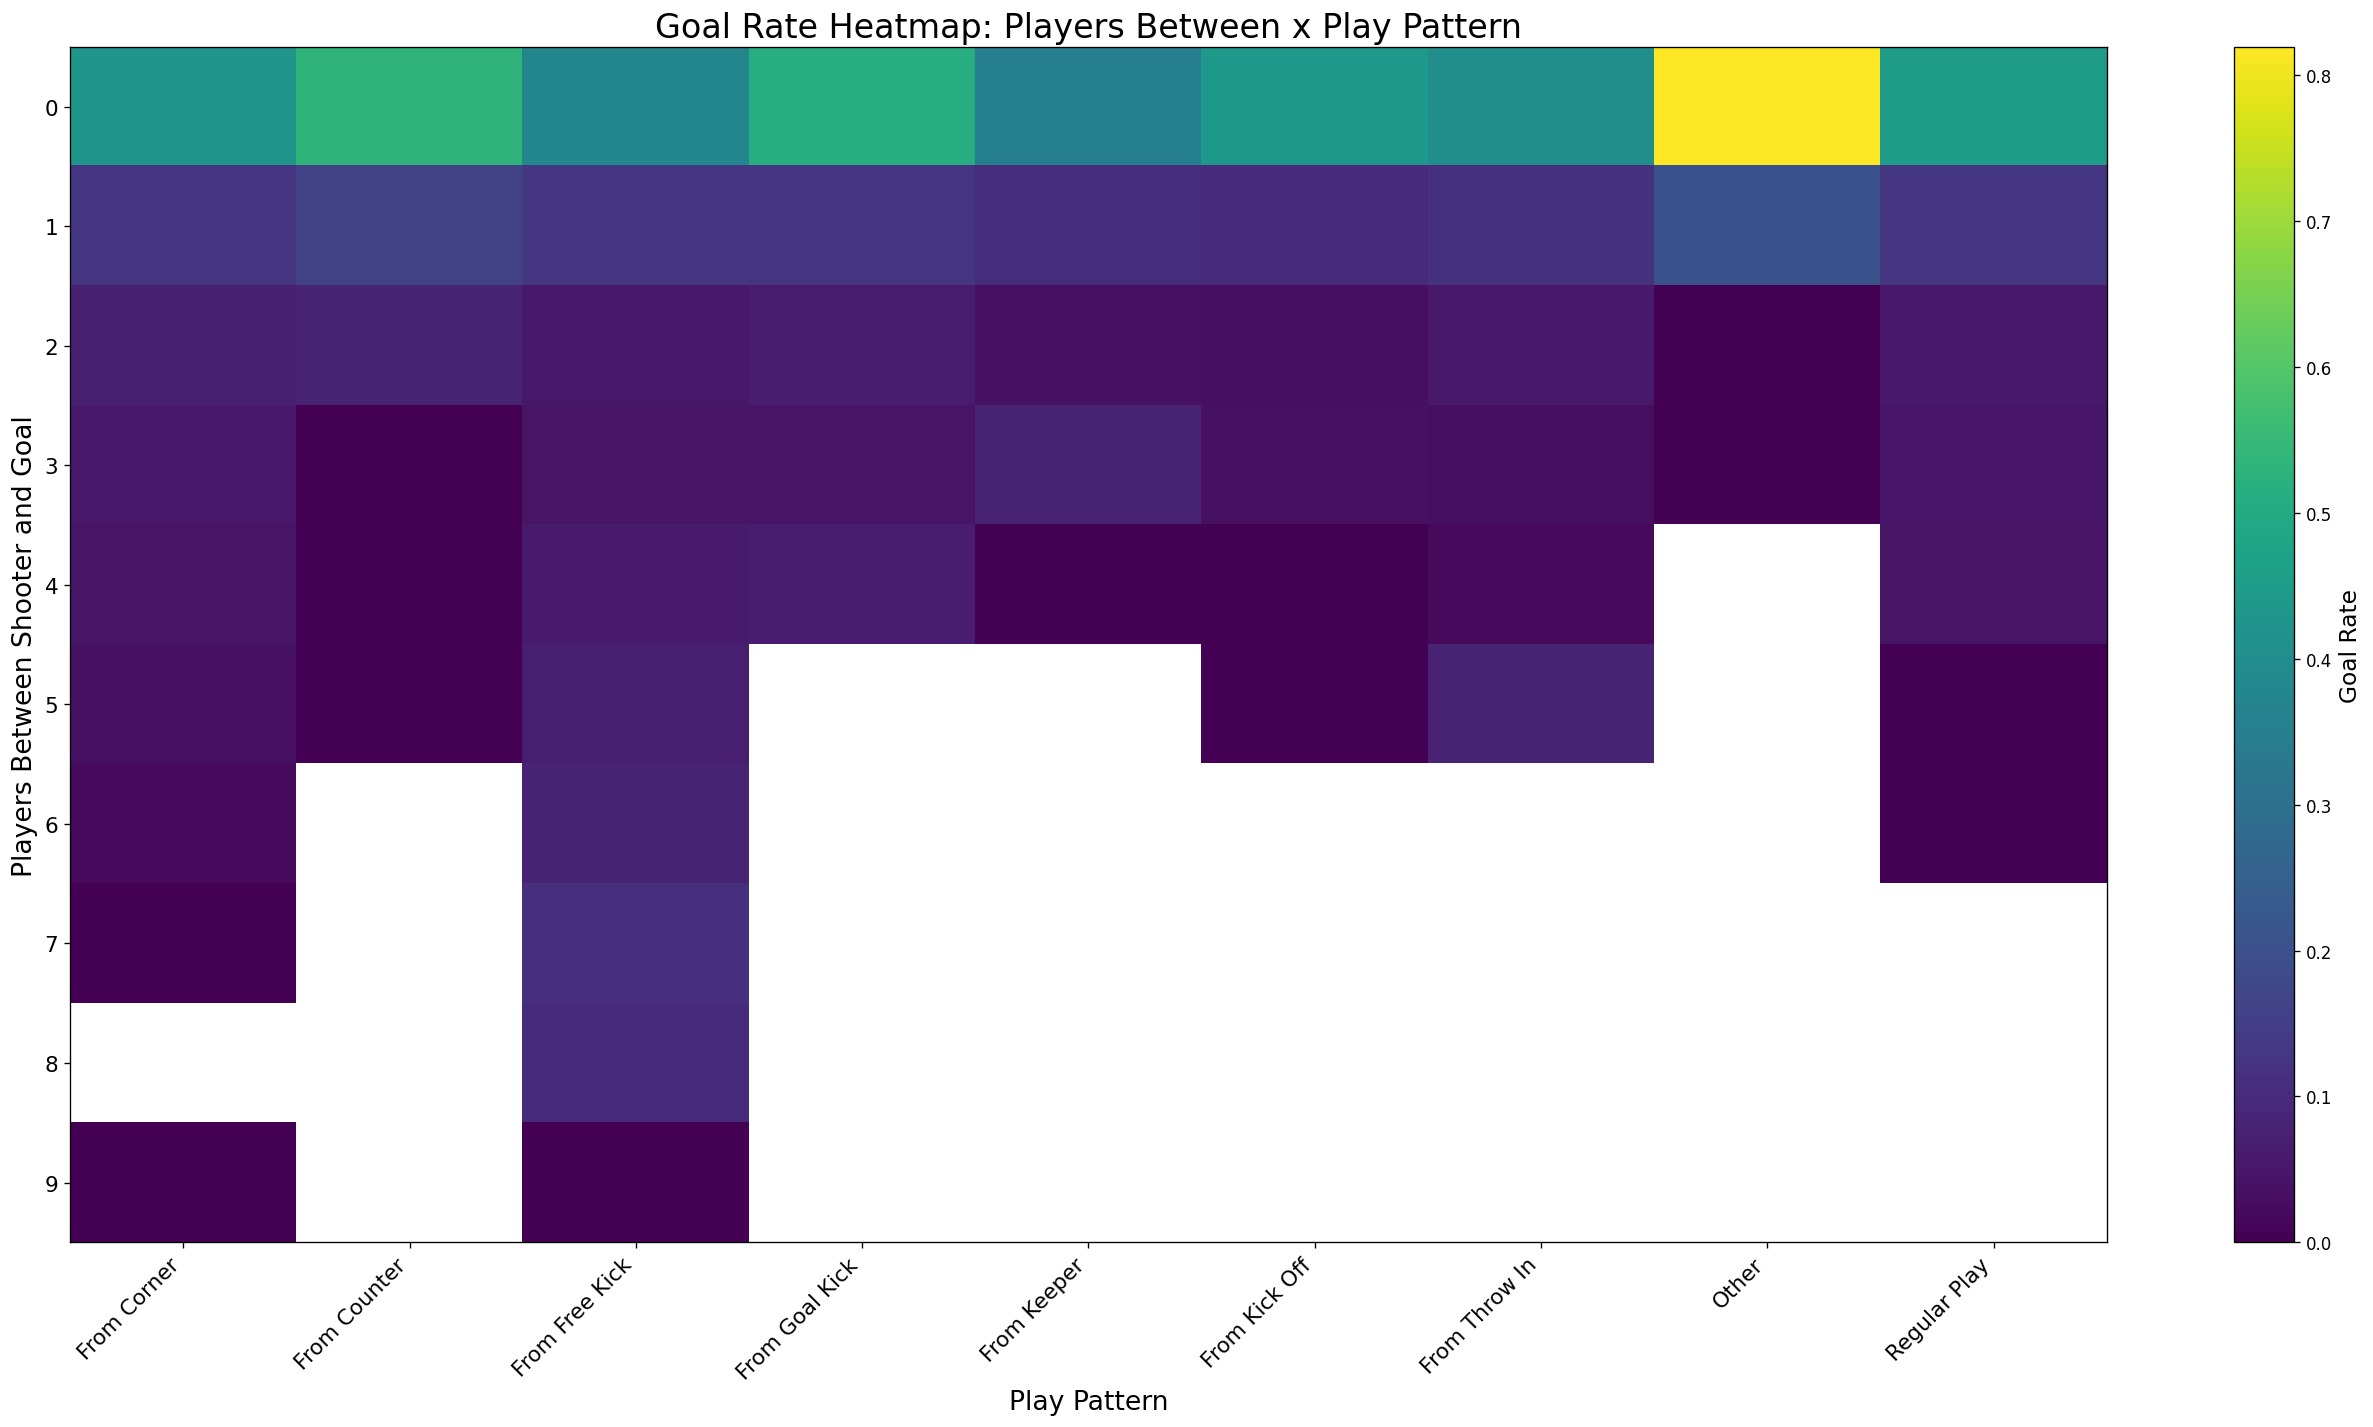

,players_between_shooter_and_goal,play_pattern,total_goals,total_shots,goal_rate
0,0,From Corner,58.0,136,0.426471
1,0,From Counter,58.0,109,0.532110
2,0,From Free Kick,69.0,183,0.377049
3,0,From Goal Kick,22.0,43,0.511628
4,0,From Keeper,6.0,17,0.352941
5,0,From Kick Off,7.0,16,0.437500
6,0,From Throw In,69.0,170,0.405882
7,0,Other,454.0,554,0.819495
8,0,Regular Play,191.0,426,0.448357
9,1,From Corner,241.0,1908,0.126310


,players_between_shooter_and_goal,total_goals,total_shots,goal_rate
0,0,934.0,1654,0.564692
1,1,2400.0,18791,0.127721
2,2,759.0,12862,0.059011
3,3,192.0,4144,0.046332
4,4,81.0,1635,0.049541
5,5,38.0,650,0.058462
6,6,12.0,191,0.062827
7,7,5.0,56,0.089286
8,8,1.0,10,0.100000
9,9,0.0,7,0.000000


In [ ]:
# Smoothed goal-rate heatmap: players_between_shooter_and_goal x play_pattern
df_plot = full_features_df.copy()

required_cols = ["is_goal", "players_between_shooter_and_goal", "play_pattern"]
missing_cols = [c for c in required_cols if c not in df_plot.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

df_plot["is_goal"] = pd.to_numeric(df_plot["is_goal"], errors="coerce")
df_plot["players_between_shooter_and_goal"] = pd.to_numeric(
    df_plot["players_between_shooter_and_goal"], errors="coerce"
)

df_plot = df_plot.dropna(subset=["is_goal", "players_between_shooter_and_goal", "play_pattern"])
df_plot["players_between_shooter_and_goal"] = df_plot["players_between_shooter_and_goal"].astype(int)

interaction_goal_rate_df = (
    df_plot.groupby(["players_between_shooter_and_goal", "play_pattern"], as_index=False)["is_goal"]
    .agg(total_goals="sum", total_shots="count")
)
interaction_goal_rate_df["goal_rate"] = (
    interaction_goal_rate_df["total_goals"] / interaction_goal_rate_df["total_shots"]
)

# Empirical-Bayes smoothing toward the global conversion rate
global_rate = df_plot["is_goal"].mean()
k = 100
alpha = global_rate * k
beta_prior = (1 - global_rate) * k

interaction_goal_rate_df["goal_rate_smoothed"] = (
    interaction_goal_rate_df["total_goals"] + alpha
) / (
    interaction_goal_rate_df["total_shots"] + alpha + beta_prior
)

heatmap_df = interaction_goal_rate_df.pivot(
    index="players_between_shooter_and_goal",
    columns="play_pattern",
    values="goal_rate_smoothed"
)

fig, ax = plt.subplots(figsize=(22, 12), dpi=120)
im = ax.imshow(heatmap_df.fillna(np.nan).values, aspect="auto", cmap="viridis")

ax.set_title("Smoothed Goal Rate Heatmap: Players Between x Play Pattern", fontsize=20)
ax.set_xlabel("Play Pattern", fontsize=16)
ax.set_ylabel("Players Between Shooter and Goal", fontsize=16)
ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns.astype(str), rotation=45, ha="right", fontsize=13)
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index.astype(str), fontsize=13)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Smoothed Goal Rate", fontsize=14)

plt.tight_layout()
plt.show()

display(interaction_goal_rate_df.sort_values(["players_between_shooter_and_goal", "play_pattern"]))


- This done confirm the theory that the reason for larger goal rates for players between shooter and goal at high values, is due to set pieces, however the true reason is a small sample size relative to other distances. 
- As a result, one goal will skew the data more to larger values. 

,players_between_shooter_and_goal,total_shots,total_goals,goal_rate,goal_rate_smoothed,goal_rate_lower,goal_rate_upper
0,0,1654,934.0,0.5647,0.5388,0.5154,0.5621
1,1,18791,2400.0,0.1277,0.1276,0.1229,0.1324
2,2,12862,759.0,0.0590,0.0594,0.0554,0.0635
3,3,4144,192.0,0.0463,0.0478,0.0416,0.0545
4,4,1635,81.0,0.0495,0.0531,0.0430,0.0641
5,5,650,38.0,0.0585,0.0654,0.0489,0.0842
6,6,191,12.0,0.0628,0.0792,0.0511,0.1128
7,7,56,5.0,0.0893,0.1029,0.0604,0.1550
8,8,10,1.0,0.1000,0.1096,0.0586,0.1740
9,9,7,0.0,0.0000,0.1033,0.0533,0.1673


<Axes: xlabel='players_between_shooter_and_goal'>

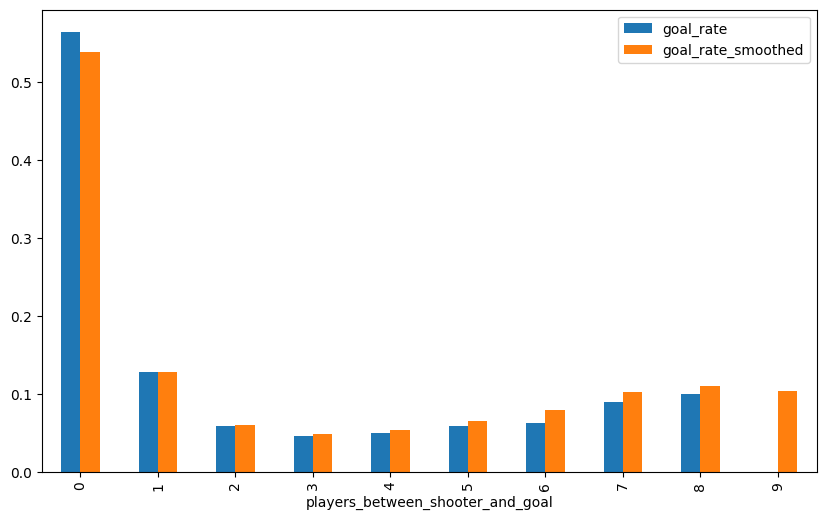

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import beta

# Copy dataframe
df = goal_rate_df.copy()

# Global conversion rate
global_rate = df["total_goals"].sum() / df["total_shots"].sum()

# Prior strength (adjust as desired)
k = 100

# Beta prior parameters
alpha = global_rate * k
beta_prior = (1 - global_rate) * k

# Posterior parameters
df["post_alpha"] = df["total_goals"] + alpha
df["post_beta"] = (df["total_shots"] - df["total_goals"]) + beta_prior

# Posterior mean (smoothed estimate)
df["goal_rate_smoothed"] = (
    df["post_alpha"] /
    (df["post_alpha"] + df["post_beta"])
)

# 95% credible intervals
df["goal_rate_lower"] = beta.ppf(
    0.025,
    df["post_alpha"],
    df["post_beta"]
)

df["goal_rate_upper"] = beta.ppf(
    0.975,
    df["post_alpha"],
    df["post_beta"]
)

# Display
display_cols = [
    "players_between_shooter_and_goal",
    "total_shots",
    "total_goals",
    "goal_rate",
    "goal_rate_smoothed",
    "goal_rate_lower",
    "goal_rate_upper"
]

display(
    df[display_cols]
    .sort_values("players_between_shooter_and_goal")
    .round(4)
)

df.plot(kind = "bar", x = "players_between_shooter_and_goal", y = ["goal_rate", "goal_rate_smoothed"], figsize=(10,6), legend=True)

### Model Development

In football data there are three basic types of datasets that accompany shot data
- xy coordinate data 
    - from this can determine shot distance, shot angle

- advanced xy coodinate data 
   - from this can have further features like shot_body_part, shot_technique... etc.. 
   - we knowfrom the analysis above these have an impact on goal scoring probabilities from our dataset

- 360 or player tracking data
  - with this we are able to determine full model. 


#### Goal of Model
The ultimate goal of the model is to be able to generate a GLM (general linear model), for each dataset feature and compare against each other
- expectation should be the model with richer features should provide more accurate results. 

#### Model Evaluation
There are two ways the model can be evaluated 
1) using statsbomb_xg values as a source of truth 
2) standard probability model evalution methods such as logloss, ROC AUC, and Brier Scores

{'model': 'xg_full', 'roc_auc': 0.8169037526802134, 'log_loss': 0.2664970157294258, 'brier': 0.07577330994463607}


,feature,coefficient,abs_coefficient
16,cat__shot_technique_Backheel,-1.296188,1.296188
21,cat__shot_technique_Overhead Kick,-1.068164,1.068164
11,bin__is_open_goal,1.033663,1.033663
37,cat__play_pattern_Other,0.959456,0.959456
12,cat__shot_body_part_Head,-0.945378,0.945378
14,cat__shot_body_part_Other,-0.934037,0.934037
17,cat__shot_technique_Diving Header,0.752294,0.752294
3,num__goalkeeper_shooter_distance,-0.722613,0.722613
19,cat__shot_technique_Lob,0.623320,0.623320
34,cat__play_pattern_From Keeper,-0.560834,0.560834


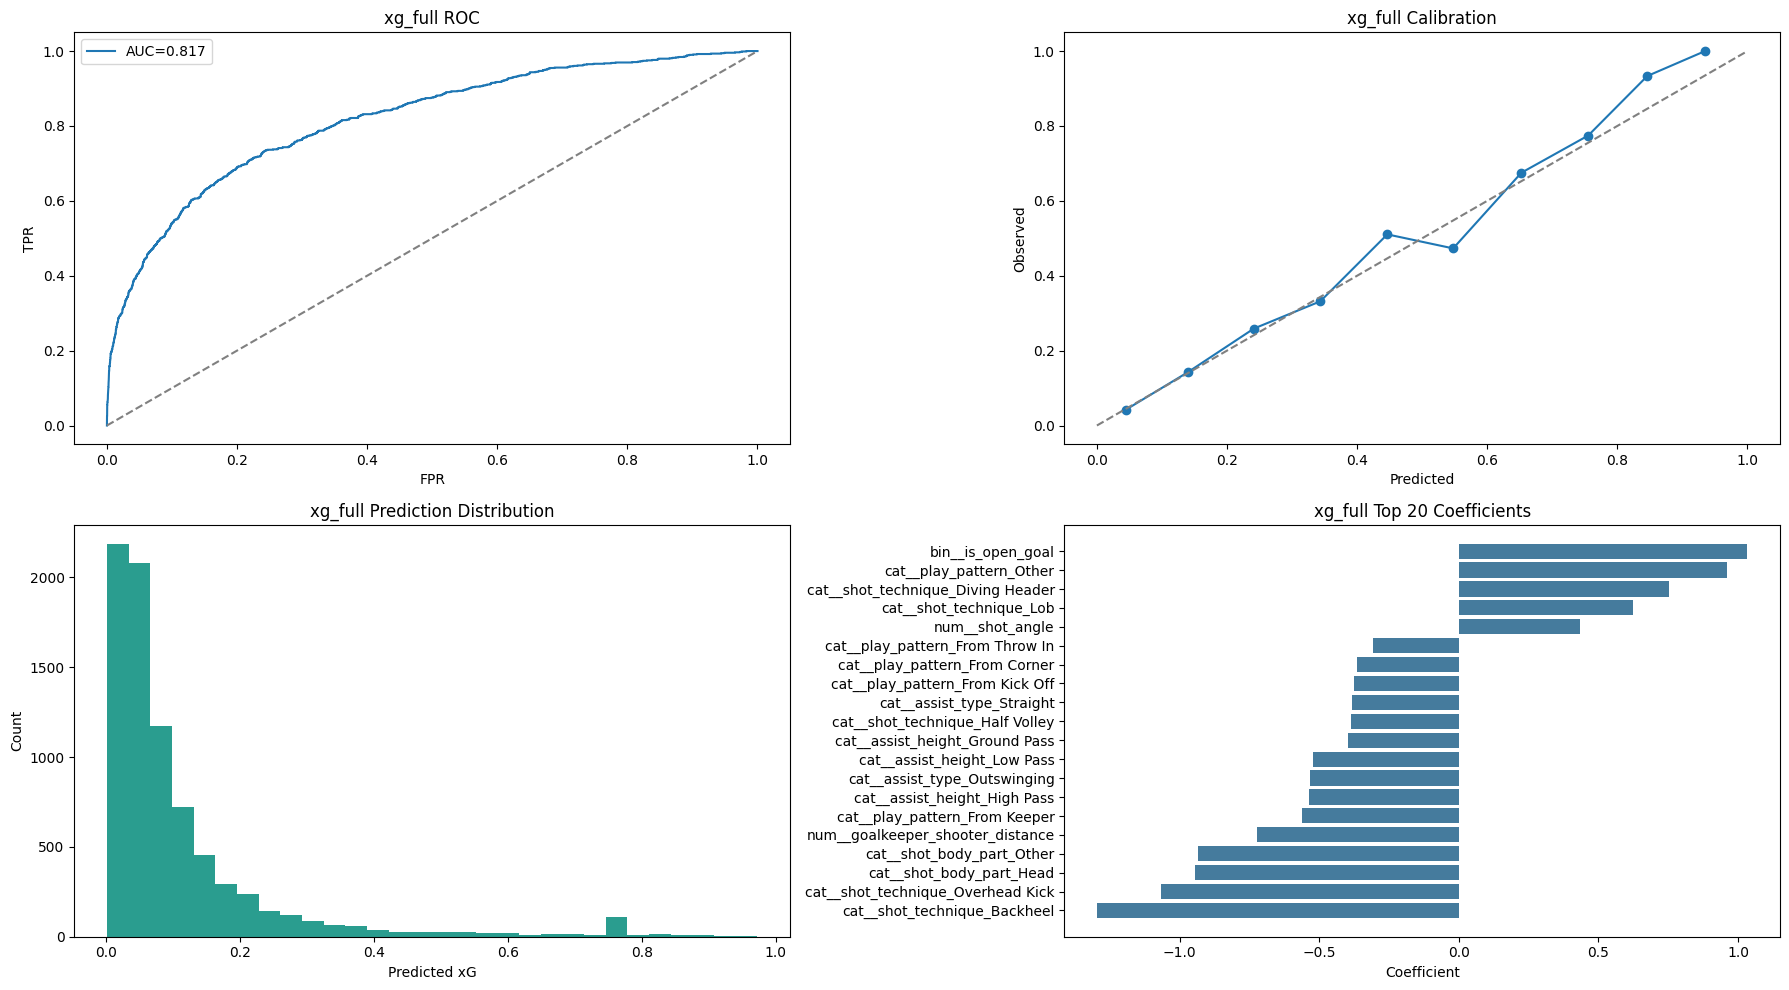

In [24]:
# xg_full model: train + plots

full_cont_cols = [
    "shot_angle",
    "shot_distance",
    "shot_distance_angle",
    "goalkeeper_shooter_distance",
    "goalkeeper_shooter_angle",
    "goalkeeper_shooter_distance_angle",
    "players_between_shooter_and_goal",
]
full_bin_cols = [
    "shot_first_time",
    "shot_follows_dribble",
    "under_pressure",
    "is_open_goal",
]
full_cat_cols = [
    "shot_body_part",
    "shot_technique",
    "assist_type",
    "assist_height",
    "play_pattern",
]
full_pressure_col = "defensive_pressure"

xg_full_features = full_cont_cols + full_bin_cols + full_cat_cols + [full_pressure_col]
xg_full_df = full_features_df.copy()

for col in full_bin_cols:
    if col in xg_full_df.columns:
        xg_full_df[col] = (
            xg_full_df[col]
            .replace({"True": 1, "False": 0, True: 1, False: 0})
            .fillna(0)
            .astype(int)
        )

X_full = xg_full_df[xg_full_features].copy()
y_full = xg_full_df["is_goal"].astype(int)

X_full_train, X_full_test, y_full_train, y_full_test = train_test_split(
    X_full,
    y_full,
    test_size=0.2,
    random_state=42,
    stratify=y_full,
)

xg_full_preprocess = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        full_cont_cols + [full_pressure_col],
    ),
    (
        "bin",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
        ]),
        full_bin_cols,
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]),
        full_cat_cols,
    ),
])

xg_full = Pipeline([
    ("prep", xg_full_preprocess),
    ("logit", LogisticRegression(max_iter=3000, solver="lbfgs")),
])

xg_full.fit(X_full_train, y_full_train)
xg_full_test_pred = xg_full.predict_proba(X_full_test)[:, 1]

xg_full_metrics = {
    "model": "xg_full",
    "roc_auc": roc_auc_score(y_full_test, xg_full_test_pred),
    "log_loss": log_loss(y_full_test, xg_full_test_pred),
    "brier": brier_score_loss(y_full_test, xg_full_test_pred),
}

# Coefficient table for xg_full
xg_full_feature_names = xg_full.named_steps["prep"].get_feature_names_out()
xg_full_coefs_df = pd.DataFrame({
    "feature": xg_full_feature_names,
    "coefficient": xg_full.named_steps["logit"].coef_[0],
})
xg_full_coefs_df["abs_coefficient"] = xg_full_coefs_df["coefficient"].abs()
xg_full_coefs_df = xg_full_coefs_df.sort_values("abs_coefficient", ascending=False)

print(xg_full_metrics)
display(xg_full_coefs_df.head(20))

fpr_full, tpr_full, _ = roc_curve(y_full_test, xg_full_test_pred)
frac_full, mean_full = calibration_curve(y_full_test, xg_full_test_pred, n_bins=10)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0, 0].plot(fpr_full, tpr_full, label=f"AUC={xg_full_metrics['roc_auc']:.3f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_title("xg_full ROC")
axes[0, 0].set_xlabel("FPR")
axes[0, 0].set_ylabel("TPR")
axes[0, 0].legend()

axes[0, 1].plot(mean_full, frac_full, marker="o")
axes[0, 1].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 1].set_title("xg_full Calibration")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Observed")

axes[1, 0].hist(xg_full_test_pred, bins=30, color="#2a9d8f")
axes[1, 0].set_title("xg_full Prediction Distribution")
axes[1, 0].set_xlabel("Predicted xG")
axes[1, 0].set_ylabel("Count")

coef_plot_full = xg_full_coefs_df.head(20).sort_values("coefficient")
axes[1, 1].barh(coef_plot_full["feature"], coef_plot_full["coefficient"], color="#457b9d")
axes[1, 1].set_title("xg_full Top 20 Coefficients")
axes[1, 1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()


{'model': 'xg_semi_full', 'roc_auc': 0.803922919861939, 'log_loss': 0.2740147782762762, 'brier': 0.07797511922366959}


,feature,coefficient,abs_coefficient
23,cat__play_pattern_Other,1.509200,1.509200
7,cat__shot_technique_Backheel,-1.457134,1.457134
12,cat__shot_technique_Overhead Kick,-1.318318,1.318318
10,cat__shot_technique_Lob,1.165628,1.165628
3,cat__shot_body_part_Head,-1.146507,1.146507
1,num__shot_distance,-1.019073,1.019073
5,cat__shot_body_part_Other,-0.888267,0.888267
8,cat__shot_technique_Diving Header,0.845100,0.845100
26,cat__under_pressure_1,-0.764964,0.764964
16,cat__play_pattern_From Corner,-0.674341,0.674341


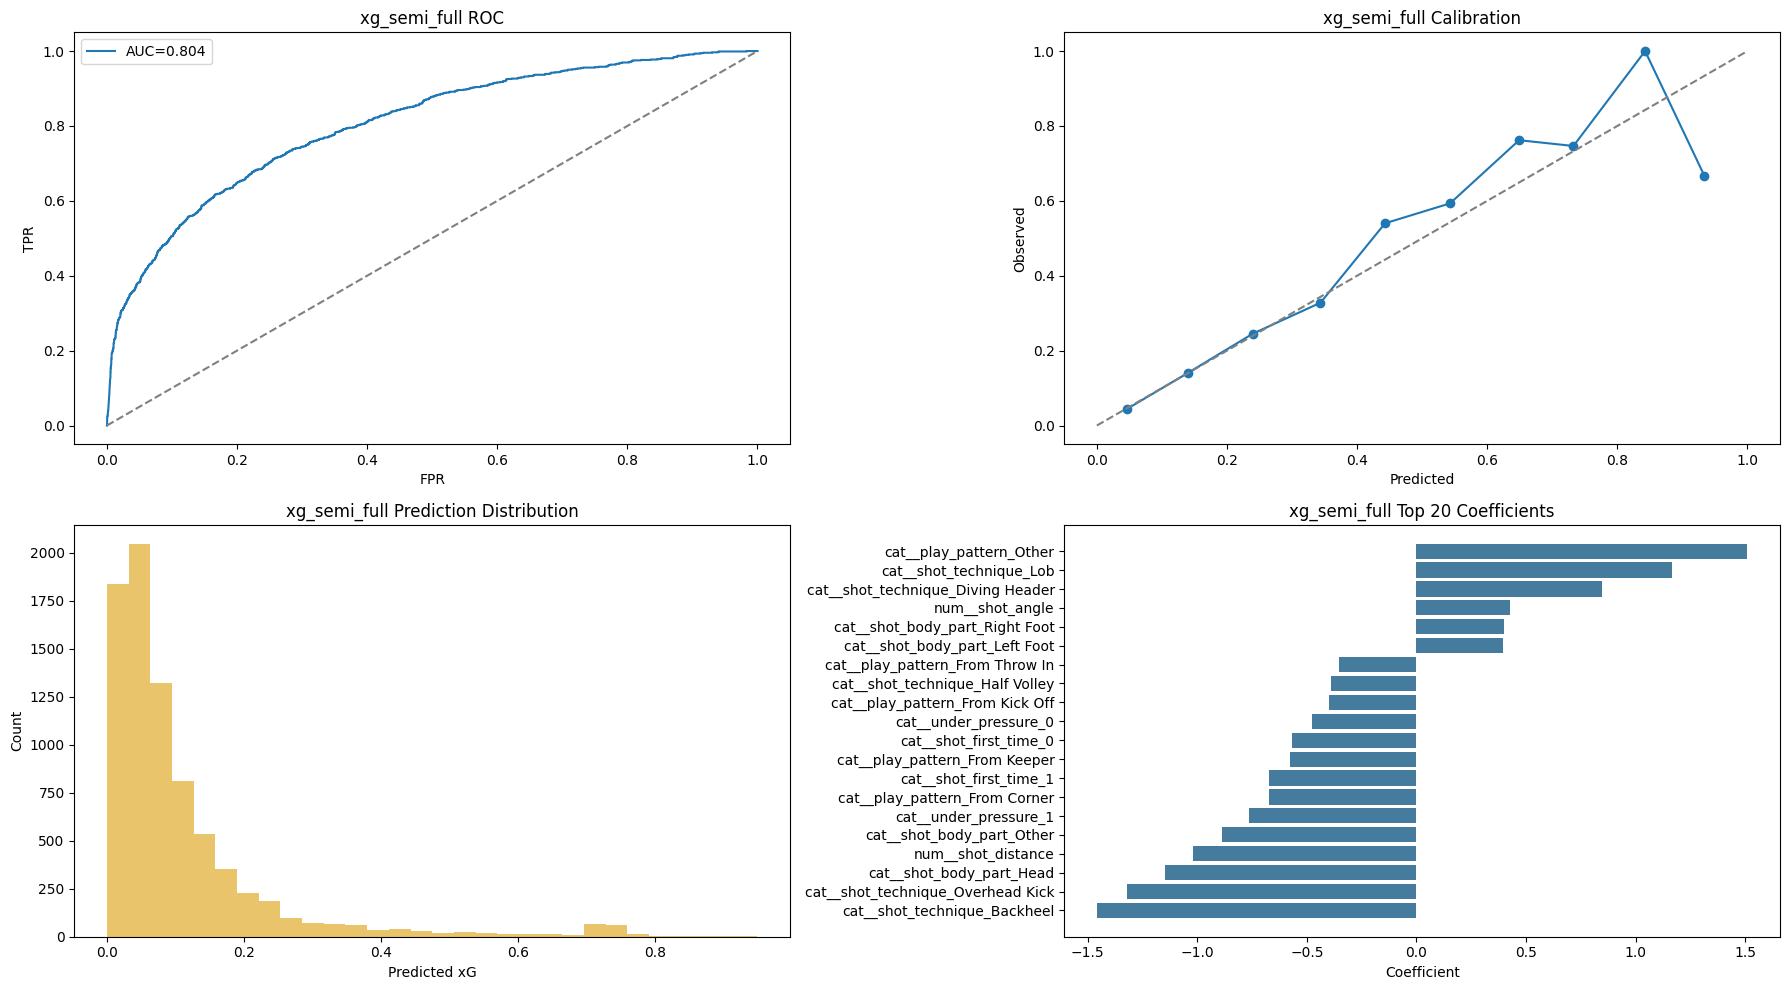

In [25]:
# xg_semi_full model: train + plots
semi_cont_cols = [
    "shot_angle",
    "shot_distance",
    "shot_distance_angle",
]
semi_cat_cols = [
    "shot_body_part",
    "shot_technique",
    "shot_first_time",
    "play_pattern",
    "under_pressure",
]

xg_semi_full_features = semi_cont_cols + semi_cat_cols
xg_semi_df = semi_full_df.copy()

for col in ["shot_first_time", "under_pressure"]:
    if col in xg_semi_df.columns:
        xg_semi_df[col] = (
            xg_semi_df[col]
            .replace({"True": 1, "False": 0, True: 1, False: 0})
            .fillna(0)
            .astype(str)
        )

X_semi = xg_semi_df[xg_semi_full_features].copy()
y_semi = xg_semi_df["is_goal"].astype(int)

X_semi_train, X_semi_test, y_semi_train, y_semi_test = train_test_split(
    X_semi,
    y_semi,
    test_size=0.2,
    random_state=42,
    stratify=y_semi,
)

xg_semi_full_preprocess = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        semi_cont_cols,
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]),
        semi_cat_cols,
    ),
])

xg_semi_full = Pipeline([
    ("prep", xg_semi_full_preprocess),
    ("logit", LogisticRegression(max_iter=3000, solver="lbfgs")),
])

xg_semi_full.fit(X_semi_train, y_semi_train)
xg_semi_full_test_pred = xg_semi_full.predict_proba(X_semi_test)[:, 1]

xg_semi_full_metrics = {
    "model": "xg_semi_full",
    "roc_auc": roc_auc_score(y_semi_test, xg_semi_full_test_pred),
    "log_loss": log_loss(y_semi_test, xg_semi_full_test_pred),
    "brier": brier_score_loss(y_semi_test, xg_semi_full_test_pred),
}

# Coefficient table for xg_semi_full
xg_semi_feature_names = xg_semi_full.named_steps["prep"].get_feature_names_out()
xg_semi_full_coefs_df = pd.DataFrame({
    "feature": xg_semi_feature_names,
    "coefficient": xg_semi_full.named_steps["logit"].coef_[0],
})
xg_semi_full_coefs_df["abs_coefficient"] = xg_semi_full_coefs_df["coefficient"].abs()
xg_semi_full_coefs_df = xg_semi_full_coefs_df.sort_values("abs_coefficient", ascending=False)

print(xg_semi_full_metrics)
display(xg_semi_full_coefs_df.head(20))

fpr_semi, tpr_semi, _ = roc_curve(y_semi_test, xg_semi_full_test_pred)
frac_semi, mean_semi = calibration_curve(y_semi_test, xg_semi_full_test_pred, n_bins=10)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0, 0].plot(fpr_semi, tpr_semi, label=f"AUC={xg_semi_full_metrics['roc_auc']:.3f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_title("xg_semi_full ROC")
axes[0, 0].set_xlabel("FPR")
axes[0, 0].set_ylabel("TPR")
axes[0, 0].legend()

axes[0, 1].plot(mean_semi, frac_semi, marker="o")
axes[0, 1].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 1].set_title("xg_semi_full Calibration")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Observed")

axes[1, 0].hist(xg_semi_full_test_pred, bins=30, color="#e9c46a")
axes[1, 0].set_title("xg_semi_full Prediction Distribution")
axes[1, 0].set_xlabel("Predicted xG")
axes[1, 0].set_ylabel("Count")

coef_plot_semi = xg_semi_full_coefs_df.head(20).sort_values("coefficient")
axes[1, 1].barh(coef_plot_semi["feature"], coef_plot_semi["coefficient"], color="#457b9d")
axes[1, 1].set_title("xg_semi_full Top 20 Coefficients")
axes[1, 1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()


{'model': 'xg_simple', 'roc_auc': 0.7582295744215445, 'log_loss': 0.3037897316195882, 'brier': 0.08872038941892593}


,feature,coefficient,abs_coefficient
1,num__shot_distance,-0.807930,0.807930
0,num__shot_angle,0.230542,0.230542
2,num__shot_distance_angle,0.146810,0.146810


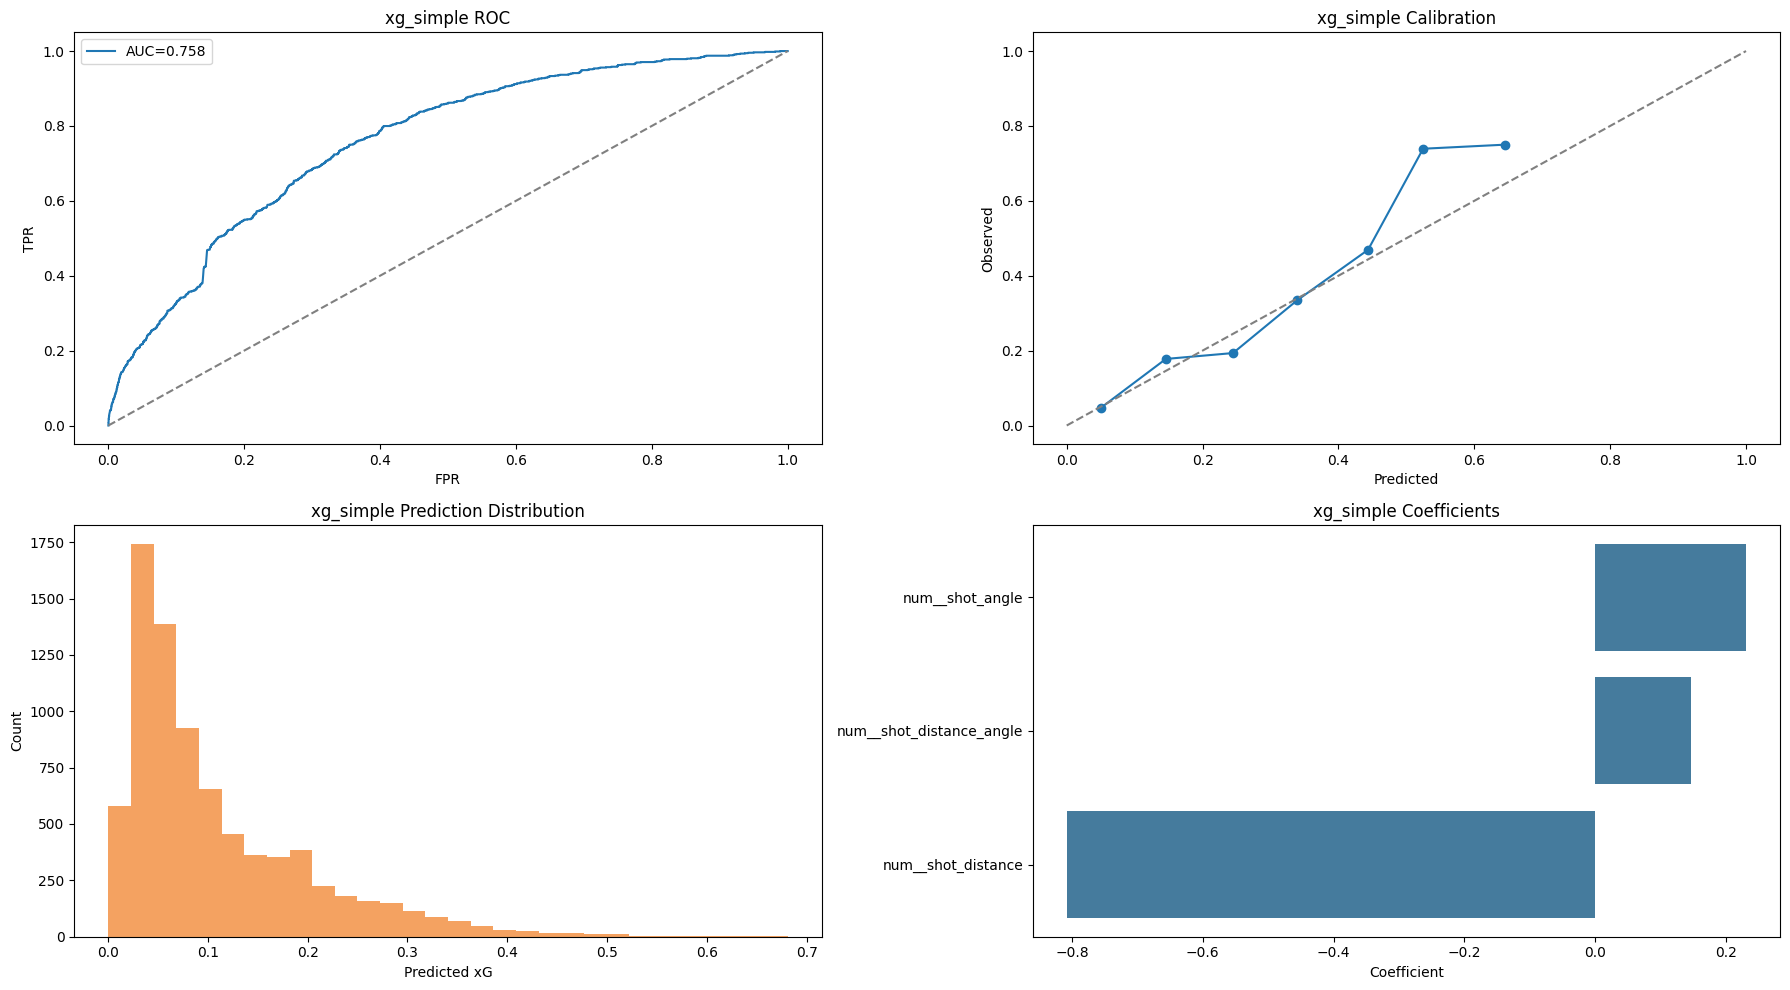

In [26]:
# xg_simple model: train + plots
simple_features = [
    "shot_angle",
    "shot_distance",
    "shot_distance_angle",
]

xg_simple_df = simple_model_df.copy()
X_simple = xg_simple_df[simple_features].copy()
y_simple = xg_simple_df["is_goal"].astype(int)

X_simple_train, X_simple_test, y_simple_train, y_simple_test = train_test_split(
    X_simple,
    y_simple,
    test_size=0.2,
    random_state=42,
    stratify=y_simple,
)

xg_simple_preprocess = ColumnTransformer([
    (
        "num",
        Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]),
        simple_features,
    ),
])

xg_simple = Pipeline([
    ("prep", xg_simple_preprocess),
    ("logit", LogisticRegression(max_iter=3000, solver="lbfgs")),
])

xg_simple.fit(X_simple_train, y_simple_train)
xg_simple_test_pred = xg_simple.predict_proba(X_simple_test)[:, 1]

xg_simple_metrics = {
    "model": "xg_simple",
    "roc_auc": roc_auc_score(y_simple_test, xg_simple_test_pred),
    "log_loss": log_loss(y_simple_test, xg_simple_test_pred),
    "brier": brier_score_loss(y_simple_test, xg_simple_test_pred),
}

# Coefficient table for xg_simple
xg_simple_feature_names = xg_simple.named_steps["prep"].get_feature_names_out()
xg_simple_coefs_df = pd.DataFrame({
    "feature": xg_simple_feature_names,
    "coefficient": xg_simple.named_steps["logit"].coef_[0],
})
xg_simple_coefs_df["abs_coefficient"] = xg_simple_coefs_df["coefficient"].abs()
xg_simple_coefs_df = xg_simple_coefs_df.sort_values("abs_coefficient", ascending=False)

print(xg_simple_metrics)
display(xg_simple_coefs_df)

fpr_simple, tpr_simple, _ = roc_curve(y_simple_test, xg_simple_test_pred)
frac_simple, mean_simple = calibration_curve(y_simple_test, xg_simple_test_pred, n_bins=10)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0, 0].plot(fpr_simple, tpr_simple, label=f"AUC={xg_simple_metrics['roc_auc']:.3f}")
axes[0, 0].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 0].set_title("xg_simple ROC")
axes[0, 0].set_xlabel("FPR")
axes[0, 0].set_ylabel("TPR")
axes[0, 0].legend()

axes[0, 1].plot(mean_simple, frac_simple, marker="o")
axes[0, 1].plot([0, 1], [0, 1], "--", color="gray")
axes[0, 1].set_title("xg_simple Calibration")
axes[0, 1].set_xlabel("Predicted")
axes[0, 1].set_ylabel("Observed")

axes[1, 0].hist(xg_simple_test_pred, bins=30, color="#f4a261")
axes[1, 0].set_title("xg_simple Prediction Distribution")
axes[1, 0].set_xlabel("Predicted xG")
axes[1, 0].set_ylabel("Count")

coef_plot_simple = xg_simple_coefs_df.sort_values("coefficient")
axes[1, 1].barh(coef_plot_simple["feature"], coef_plot_simple["coefficient"], color="#457b9d")
axes[1, 1].set_title("xg_simple Coefficients")
axes[1, 1].set_xlabel("Coefficient")

plt.tight_layout()
plt.show()


                   roc_auc  log_loss   brier
model                                       
xg_full             0.8169    0.2665  0.0758
xg_semi_full        0.8039    0.2740  0.0780
xg_simple           0.7582    0.3038  0.0887
shot_statsbomb_xg   0.8300    0.2605  0.0743


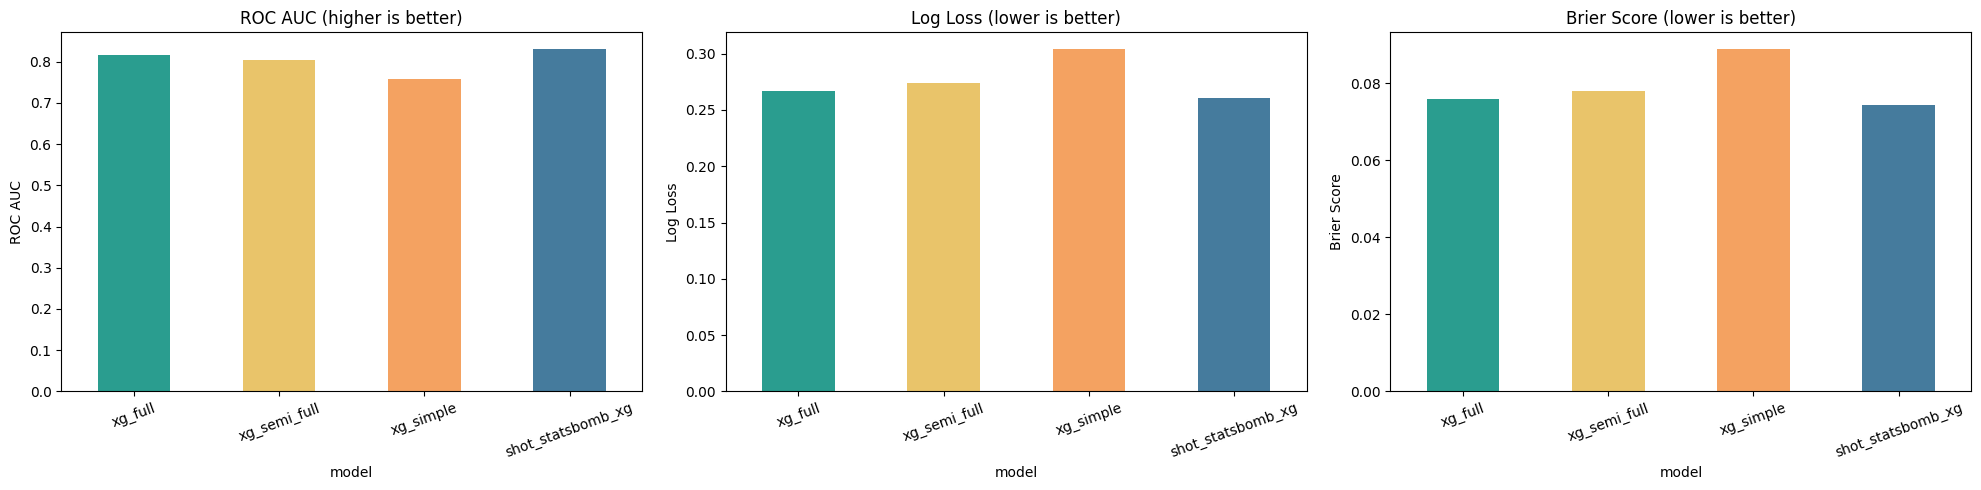

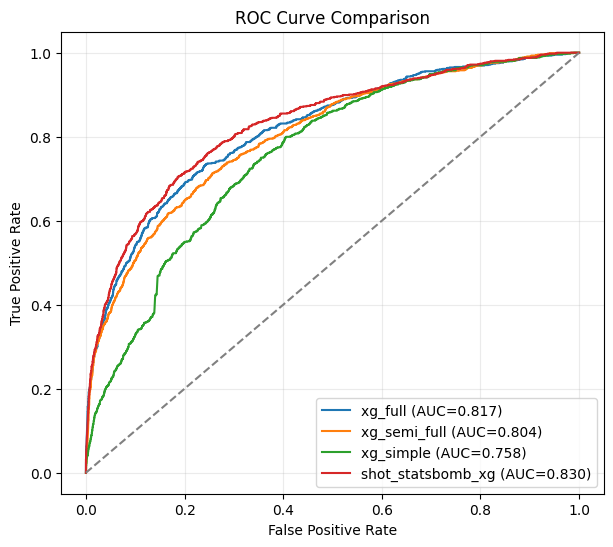

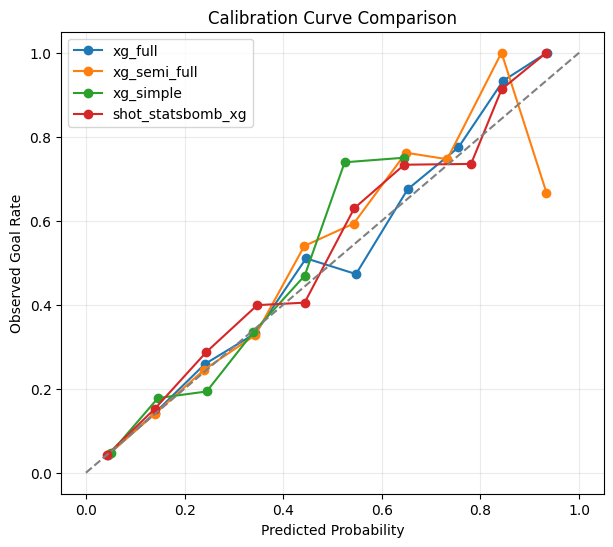

In [27]:
# Compare xg_full vs xg_semi_full vs xg_simple + StatsBomb baseline (shot_statsbomb_xg)
# Baseline is evaluated on the same holdout used by xg_full for direct comparison
statsbomb_full_test_pred = pd.to_numeric(
    xg_full_df.loc[X_full_test.index, "shot_statsbomb_xg"],
    errors="coerce"
).fillna(0).clip(0, 1)

statsbomb_metrics = {
    "model": "shot_statsbomb_xg",
    "roc_auc": roc_auc_score(y_full_test, statsbomb_full_test_pred),
    "log_loss": log_loss(y_full_test, statsbomb_full_test_pred),
    "brier": brier_score_loss(y_full_test, statsbomb_full_test_pred),
}

comparison_df = pd.DataFrame([
    xg_full_metrics,
    xg_semi_full_metrics,
    xg_simple_metrics,
    statsbomb_metrics,
]).set_index("model")

print(comparison_df.round(4))

bar_colors = ["#2a9d8f", "#e9c46a", "#f4a261", "#457b9d"]
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

comparison_df["roc_auc"].plot(kind="bar", ax=axes[0], color=bar_colors)
axes[0].set_title("ROC AUC (higher is better)")
axes[0].set_ylabel("ROC AUC")
axes[0].tick_params(axis="x", rotation=20)

comparison_df["log_loss"].plot(kind="bar", ax=axes[1], color=bar_colors)
axes[1].set_title("Log Loss (lower is better)")
axes[1].set_ylabel("Log Loss")
axes[1].tick_params(axis="x", rotation=20)

comparison_df["brier"].plot(kind="bar", ax=axes[2], color=bar_colors)
axes[2].set_title("Brier Score (lower is better)")
axes[2].set_ylabel("Brier Score")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

# ROC curve comparison including StatsBomb xG
fpr_statsbomb, tpr_statsbomb, _ = roc_curve(y_full_test, statsbomb_full_test_pred)

plt.figure(figsize=(7, 6))
plt.plot(fpr_full, tpr_full, label=f"xg_full (AUC={xg_full_metrics['roc_auc']:.3f})")
plt.plot(fpr_semi, tpr_semi, label=f"xg_semi_full (AUC={xg_semi_full_metrics['roc_auc']:.3f})")
plt.plot(fpr_simple, tpr_simple, label=f"xg_simple (AUC={xg_simple_metrics['roc_auc']:.3f})")
plt.plot(fpr_statsbomb, tpr_statsbomb, label=f"shot_statsbomb_xg (AUC={statsbomb_metrics['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Calibration comparison including StatsBomb xG
frac_statsbomb, mean_statsbomb = calibration_curve(y_full_test, statsbomb_full_test_pred, n_bins=10)

plt.figure(figsize=(7, 6))
plt.plot(mean_full, frac_full, marker="o", label="xg_full")
plt.plot(mean_semi, frac_semi, marker="o", label="xg_semi_full")
plt.plot(mean_simple, frac_simple, marker="o", label="xg_simple")
plt.plot(mean_statsbomb, frac_statsbomb, marker="o", label="shot_statsbomb_xg")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("Calibration Curve Comparison")
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Goal Rate")
plt.legend()
plt.grid(alpha=0.25)
plt.show()
